# PhonePe Digital Payments Case Study
### Analyzing Transaction and Demographic Data Across Indian States (2018–2021)

**Author:** Madhav Bhatnagar
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

This notebook analyzes PhonePe transaction, user, device, and demographic
data to uncover trends in digital payment adoption across India.

## Task 1: Data Loading and Understanding

In [1]:

import pandas as pd

state_txn = pd.read_excel("phonepe_data.xlsx", sheet_name="State_Txn and Users")
state_split = pd.read_excel("phonepe_data.xlsx", sheet_name="State_TxnSplit")
state_device = pd.read_excel("phonepe_data.xlsx", sheet_name="State_DeviceData")
district_txn = pd.read_excel("phonepe_data.xlsx", sheet_name="District_Txn and Users")
district_demo = pd.read_excel("phonepe_data.xlsx", sheet_name="District Demographics")

#### 1. Load the State_Txn and Users dataset and display its first 5 rows.

In [2]:
state_txn.head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


#### 2. Load the State_TxnSplit dataset and display its bottom 10 rows.

In [3]:
state_split.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


#### 3. Load the State_DeviceData dataset and display 10 rows from the middle of the dataset

In [4]:
mid=len(state_device)//2
state_device.iloc[mid:mid+10]

,State,Year,Quarter,Brand,Registered Users,Percentage
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900
2777,Lakshadweep,2018,1,OnePlus,22,0.043912
2778,Lakshadweep,2018,1,Apple,20,0.039920
2779,Lakshadweep,2018,1,Realme,20,0.039920
2780,Lakshadweep,2018,1,Gionee,12,0.023952
2781,Lakshadweep,2018,1,COOLPAD,10,0.019960


#### 4. Load the District_Txn and Users dataset and display its first 10 rows and last 10 rows.

In [5]:
district_txn.head(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


In [6]:
district_txn.tail(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


#### 5. Load the District Demographics dataset and display every 10th row.

In [7]:
district_demo.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


### 1.2 : Display basic statistics and data types for each dataset



#### 1. For each dataset, display the summary statistics (mean, median, std, etc.) for numerical columns.



#### i.) State_Txn and Users

In [8]:
state_txn.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


#### ii.) State_TxnSplit

In [9]:
state_split.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,2514.000000,2514.000000,2.514000e+03,2.514000e+03,2514.000000
mean,2019.286794,2.358393,8.167446e+06,1.443978e+10,1349.927929
std,1.030807,1.109251,2.423645e+07,5.995054e+10,1534.866221
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,17.198606
25%,2018.000000,1.000000,2.788075e+04,1.762412e+07,385.735827
50%,2019.000000,2.000000,2.687980e+05,1.901189e+08,720.940406
75%,2020.000000,3.000000,3.683230e+06,2.661248e+09,1352.790116
max,2021.000000,4.000000,2.795990e+08,8.721520e+11,7767.539936


#### iii.) State_Device_Data

In [10]:
state_device.describe()

,Year,Quarter,Registered Users,Percentage
count,5544.000000,5544.000000,5.544000e+03,5544.000000
mean,2019.285714,2.357143,4.343183e+05,0.090909
std,1.030250,1.108970,9.056069e+05,0.083095
min,2018.000000,1.000000,1.000000e+01,0.006373
25%,2018.000000,1.000000,8.055750e+03,0.021588
50%,2019.000000,2.000000,7.442250e+04,0.056914
75%,2020.000000,3.000000,3.978875e+05,0.143626
max,2021.000000,4.000000,9.764252e+06,0.478367


#### iv.) District_txn and Users

In [11]:
district_txn.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,10248.000000,10248.000000,1.024800e+04,1.024800e+04,10244.000000,1.024800e+04,1.024800e+04
mean,2019.285714,2.357143,2.003607e+06,3.542311e+09,1909.796545,2.349591e+05,4.807117e+06
std,1.030208,1.108924,9.613466e+06,1.473154e+10,600.943349,4.605978e+05,1.562541e+07
min,2018.000000,1.000000,0.000000e+00,0.000000e+00,84.944283,2.200000e+01,0.000000e+00
25%,2018.000000,1.000000,1.031418e+05,1.756668e+08,1554.589051,3.619550e+04,0.000000e+00
50%,2019.000000,2.000000,3.763065e+05,6.784562e+08,1863.135530,1.067640e+05,6.403025e+05
75%,2020.000000,3.000000,1.272815e+06,2.377256e+09,2203.083552,2.573165e+05,4.346320e+06
max,2021.000000,4.000000,3.487128e+08,4.444224e+11,11209.980550,1.060461e+07,5.544197e+08


#### v.) District Demographics

In [12]:
district_demo.describe()

,Population,Area (sq km),Density
count,7.420000e+02,742.000000,742.000000
mean,1.668555e+06,4395.373120,838.512129
std,1.458849e+06,4254.676124,2754.406896
min,0.000000e+00,0.000000,0.000000
25%,6.530815e+05,2039.750000,198.000000
50%,1.322359e+06,3402.500000,353.000000
75%,2.297440e+06,5432.750000,686.250000
max,1.008285e+07,45652.000000,36155.000000


#### 2. Display the data types of each column in each dataset



#### i.) State_txn and Users

In [13]:
state_txn.dtypes

State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

#### ii.) State_TxnSplit

In [14]:
state_split.dtypes

State                object
Year                  int64
Quarter               int64
Transaction Type     object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

#### iii.) State_Device_data

In [15]:
state_device.dtypes

State                object
Year                  int64
Quarter               int64
Brand                object
Registered Users      int64
Percentage          float64
dtype: object

#### iv.) District_Txn and Users

In [16]:
district_txn.dtypes

State                object
Year                  int64
Quarter               int64
District             object
Code                 object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

#### v.) District Demographics

In [17]:
district_demo.dtypes

State              object
District           object
Headquarters       object
Population          int64
Area (sq km)      float64
Density             int64
Code               object
Alternate Name     object
dtype: object

### 1.3: Check for missing values

#### 1. Identify any missing values in each dataset.



#### i.) State_Txn and Users

In [18]:
state_txn.isnull().sum()

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64

#### ii.) State_TxnSplit


In [19]:
state_split.isnull().sum()

State               0
Year                0
Quarter             0
Transaction Type    0
Transactions        0
Amount (INR)        0
ATV (INR)           0
dtype: int64

#### iii.) State_DeviceData


In [20]:
state_device.isnull().sum()

State               0
Year                0
Quarter             0
Brand               0
Registered Users    0
Percentage          0
dtype: int64

#### iv.) District_Txn and Users


In [21]:
district_txn.isnull().sum()

State                0
Year                 0
Quarter              0
District             0
Code                28
Transactions         0
Amount (INR)         0
ATV (INR)            4
Registered Users     0
App Opens            0
dtype: int64

#### v.) District Demographics

In [22]:
district_demo.isnull().sum()

State             0
District          0
Headquarters      0
Population        0
Area (sq km)      0
Density           0
Code              0
Alternate Name    0
dtype: int64

#### 2. Calculate the percentage of missing values for each column that has missing values.



#### i.) State_Txn and Users


In [23]:
missing_pct1=(state_txn.isnull().sum()/len(state_txn))*100
missing_pct1[missing_pct1>0]

Amount (INR)    0.198413
dtype: float64

#### ii.) State_TxnSplit


In [24]:
missing_pct2=(state_split.isnull().sum()/len(state_split))*100
missing_pct2[missing_pct2>0]

Series([], dtype: float64)

#### iii.) State_DeviceData


In [25]:
missing_pct3=(state_device.isnull().sum()/len(state_device))*100
missing_pct3[missing_pct3>0]

Series([], dtype: float64)

#### iv.) District_Txn and Users

In [26]:
missing_pct4=(district_txn.isnull().sum()/len(district_txn))*100
missing_pct4[missing_pct4>0]

Code         0.273224
ATV (INR)    0.039032
dtype: float64

#### v.) District Demographics

In [27]:
missing_pct5=(district_demo.isnull().sum()/len(district_demo))*100
missing_pct5[missing_pct5>0]

Series([], dtype: float64)

#### 3. Highlight which column has the highest percentage of missing values in each dataset.

In [28]:
missing_pct1.idxmax()

'Amount (INR)'

In [29]:
missing_pct4.idxmax()


'Code'

#### 1.4: Create a summary 

#### 1. Calculate the total number of states and the total number of districts.

In [30]:
total_no_states=district_demo['State'].nunique()
total_no_districts=district_demo['District'].nunique()

#### Total Number of States

In [31]:
print(total_no_states)


36


#### Total Number of Districts

In [32]:
print(total_no_districts)

736


#### 2. Identify the state with the highest number of districts

In [33]:
Highest_nos_of_district=district_demo['State'].value_counts().idxmax()
Highest_nos_of_district

'Uttar Pradesh'

## Task 2 Exploratory Data Analysis (EDA)

### 2.1: Analyze transaction trends over the years for each state

#### 1. Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.

In [34]:
state_totals=state_txn.groupby('State')[['Transactions','Amount (INR)']].sum()

In [35]:
print(state_totals)

                                      Transactions  Amount (INR)
State                                                           
Andaman & Nicobar Islands                  1223565  3.641818e+09
Andhra Pradesh                          1781091169  3.187847e+12
Arunachal Pradesh                          8043799  2.225183e+10
Assam                                    123577981  2.814087e+11
Bihar                                    713643889  1.639579e+12
Chandigarh                                25516542  5.371208e+10
Chhattisgarh                             241908549  4.156353e+11
Dadra & Nagar Haveli and Daman & Diu      12462185  1.865878e+10
Delhi                                   1011031124  1.649942e+12
Goa                                       24481604  4.427187e+10
Gujarat                                  612992823  1.105329e+12
Haryana                                  567751410  1.059832e+12
Himachal Pradesh                          52987445  9.786546e+10
Jammu & Kashmir          

#### 2. Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.

#### TOP_5

In [36]:
top_5=state_totals.sort_values('Transactions', ascending=False).head(5)

In [37]:
print(top_5)

                Transactions  Amount (INR)
State                                     
Karnataka         2981044533  4.361396e+12
Maharashtra       2833670154  4.290995e+12
Telangana         2347430243  4.574246e+12
Andhra Pradesh    1781091169  3.187847e+12
Rajasthan         1382918930  2.625584e+12


#### BOTTOM_5

In [38]:
bottom_5=state_totals.sort_values('Transactions',ascending=True).head(5)

In [39]:
print(bottom_5)

                           Transactions  Amount (INR)
State                                                
Lakshadweep                       71610  1.921587e+08
Andaman & Nicobar Islands       1223565  3.641818e+09
Ladakh                          1880109  6.606978e+09
Mizoram                         2162776  6.317141e+09
Meghalaya                       5648913  1.254162e+10


#### 2.2: Identify the most common transaction types in each state and quarter

*Using `groupby(['State','Year','Quarter'])['Transactions'].idxmax()` to find the row index with the highest transaction count within each group, then `.loc[]` to pull the full row back using same logic as SQL's `ROW_NUMBER() OVER (PARTITION BY State, Year, Quarter ORDER BY Transactions DESC)`.*

In [40]:
idx=state_split.groupby(['State','Year','Quarter'])['Transactions'].idxmax()

In [41]:
most_common_type=state_split.loc[idx,['State','Year','Quarter','Transaction Type',]]

In [42]:
most_common_type.reset_index(drop=True, inplace=True)


In [43]:
print(most_common_type)

                         State  Year  Quarter          Transaction Type
0    Andaman & Nicobar Islands  2018        1  Recharge & bill payments
1    Andaman & Nicobar Islands  2018        2  Recharge & bill payments
2    Andaman & Nicobar Islands  2018        3  Recharge & bill payments
3    Andaman & Nicobar Islands  2018        4  Recharge & bill payments
4    Andaman & Nicobar Islands  2019        1  Recharge & bill payments
..                         ...   ...      ...                       ...
499                West Bengal  2020        2     Peer-to-peer payments
500                West Bengal  2020        3     Peer-to-peer payments
501                West Bengal  2020        4     Peer-to-peer payments
502                West Bengal  2021        1     Peer-to-peer payments
503                West Bengal  2021        2     Peer-to-peer payments

[504 rows x 4 columns]


#### 2.3: Determine the device brand with the highest number of registered users in each state


*Same `idxmax()` pattern as above, grouped only by `State` this time to find the highest `Registered Users` brand overall.*

In [44]:
idx2=state_device.groupby("State")['Registered Users'].idxmax()

In [45]:
top_brand=state_device.loc[idx2,['State','Brand','Registered Users']]

In [46]:
top_brand.reset_index(drop=True, inplace=True)

In [47]:
print(top_brand)

                                   State    Brand  Registered Users
0              Andaman & Nicobar Islands     Vivo             15056
1                         Andhra Pradesh   Xiaomi           4937684
2                      Arunachal Pradesh     Vivo             63439
3                                  Assam   Xiaomi            909274
4                                  Bihar   Xiaomi           4268361
5                             Chandigarh   Xiaomi            101761
6                           Chhattisgarh     Vivo           1169224
7   Dadra & Nagar Haveli and Daman & Diu     Vivo             87001
8                                  Delhi   Xiaomi           2731995
9                                    Goa   Xiaomi            152107
10                               Gujarat     Vivo           3834323
11                               Haryana   Xiaomi           2505880
12                      Himachal Pradesh   Xiaomi            513196
13                       Jammu & Kashmir   Xiaom

#### 2.4: Create a list of the top district per state based on population

*Same groupby + idxmax pattern applied to `district_demo`, this time on `Population`.*

#### 1. For each state, identify the district with the highest population. Display the results in a tabular format.

In [48]:
idx3=district_demo.groupby('State')['Population'].idxmax()

In [49]:
district_population=district_demo.loc[idx3,['State','District','Population']]

In [50]:
district_population.reset_index(drop=True,inplace=True)

In [51]:
print(district_population)

                                   State                District  Population
0              Andaman & Nicobar Islands           South Andaman      238142
1                         Andhra Pradesh           East Godavari     5151549
2                      Arunachal Pradesh              Papum Pare      176385
3                                  Assam                  Nagaon     2826006
4                                  Bihar                   Patna     5772804
5                             Chandigarh              Chandigarh     1055450
6                           Chhattisgarh                  Raipur     2160876
7   Dadra & Nagar Haveli and Daman & Diu  Dadra and Nagar Haveli      343709
8                                  Delhi        North West Delhi     3656539
9                                    Goa               North Goa      817761
10                               Gujarat               Ahmedabad     7208200
11                               Haryana               Faridabad     1798954

#### 2. Create a column chart depicting the district with the highest population for each state.

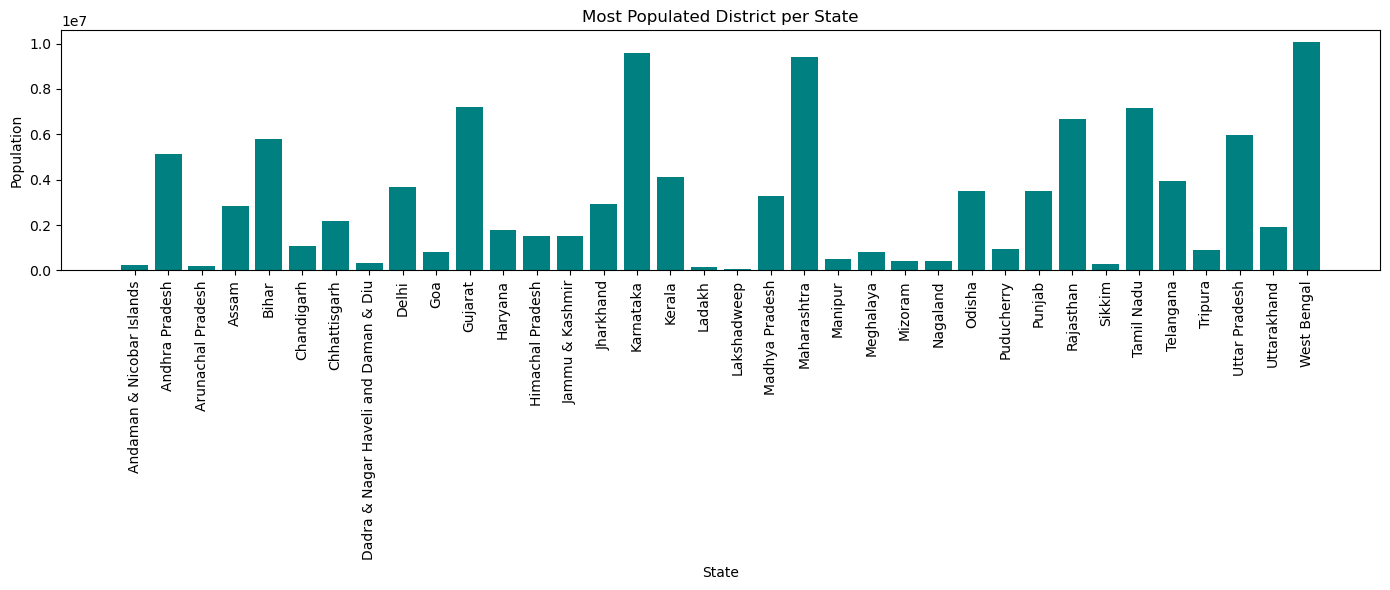

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.bar(district_population['State'], district_population['Population'], color='teal')
plt.title('Most Populated District per State')
plt.xlabel('State')
plt.ylabel('Population')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 2.5: Calculate the average transaction value (ATV) for each state

#### 1. Compute the average transaction value for each state. Display the results in a tabular format.

In [53]:
avg_atv=state_txn.groupby('State')['ATV (INR)'].mean()

In [54]:
print(avg_atv)

State
Andaman & Nicobar Islands               3159.266422
Andhra Pradesh                          1748.091476
Arunachal Pradesh                       2638.323985
Assam                                   2008.495656
Bihar                                   2023.316978
Chandigarh                              2113.797075
Chhattisgarh                            1650.818617
Dadra & Nagar Haveli and Daman & Diu    1487.395599
Delhi                                   1589.839307
Goa                                     1895.258549
Gujarat                                 1696.101220
Haryana                                 1831.840325
Himachal Pradesh                        1825.338700
Jammu & Kashmir                         2508.506029
Jharkhand                               1632.342997
Karnataka                               1517.392249
Kerala                                  1671.443173
Ladakh                                  3408.222984
Lakshadweep                             2776.118701
Madhya

#### 2. Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.

#### TOP_5 Highest ATV

In [55]:
Top_5_highest_atv=avg_atv.sort_values(ascending=False).head(5)

In [56]:
print(Top_5_highest_atv)

State
Ladakh                       3408.222984
Andaman & Nicobar Islands    3159.266422
Mizoram                      2927.517802
Lakshadweep                  2776.118701
Arunachal Pradesh            2638.323985
Name: ATV (INR), dtype: float64


#### TOP_5 Lowest ATV

In [57]:
Top_5_lowest_atv=avg_atv.sort_values(ascending=True).head(5)

In [58]:
print(Top_5_lowest_atv)

State
West Bengal                             1373.600590
Odisha                                  1428.137367
Dadra & Nagar Haveli and Daman & Diu    1487.395599
Maharashtra                             1516.361820
Karnataka                               1517.392249
Name: ATV (INR), dtype: float64


#### 2.6: Analyze app usage trends

#### 1. Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.

In [59]:
app_open_summary=district_txn.groupby(['State','Year','Quarter'])['App Opens'].sum().reset_index()

In [60]:
print(app_open_summary)

                         State  Year  Quarter  App Opens
0    Andaman & Nicobar Islands  2018        1          0
1    Andaman & Nicobar Islands  2018        2          0
2    Andaman & Nicobar Islands  2018        3          0
3    Andaman & Nicobar Islands  2018        4          0
4    Andaman & Nicobar Islands  2019        1          0
..                         ...   ...      ...        ...
499                West Bengal  2020        2  198589332
500                West Bengal  2020        3  246554831
501                West Bengal  2020        4  291721919
502                West Bengal  2021        1  316832674
503                West Bengal  2021        2  275341466

[504 rows x 4 columns]


#### 2. Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.

In [61]:
selected_state='Uttar Pradesh'
state_data=app_open_summary[app_open_summary['State']==selected_state]

In [62]:
state_data=state_data.copy()
state_data['Period'] = state_data['Year'].astype(str) + '-Q' + state_data['Quarter'].astype(str)

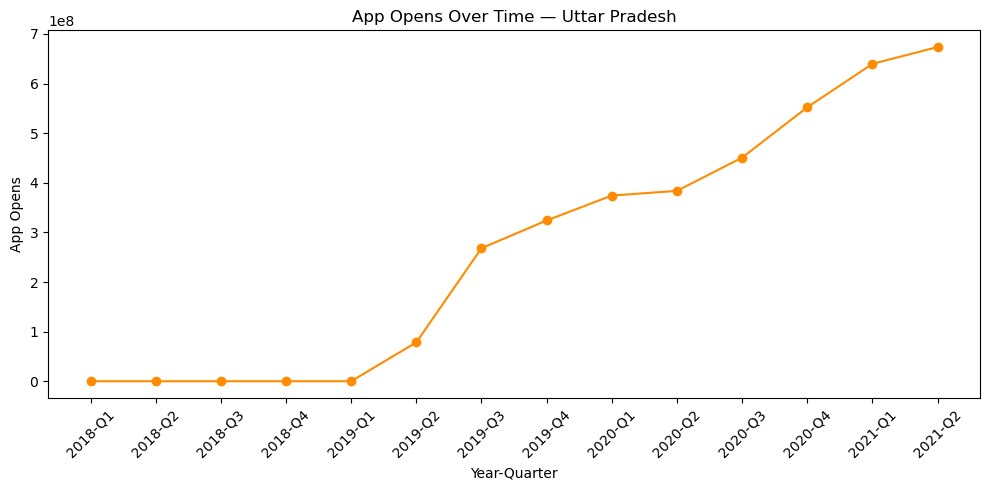

In [63]:
plt.figure(figsize=(10,5))
plt.plot(state_data['Period'], state_data['App Opens'], marker='o', color='darkorange')
plt.title(f'App Opens Over Time — {selected_state}')
plt.xlabel('Year-Quarter')
plt.ylabel('App Opens')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2.7: Distribution of transaction types

#### 1. Create a bar chart showing the distribution of different transaction types foreach state for the most recent quarter in the dataset.


In [64]:
Latest_year=state_split['Year'].max()
Latest_quarter = state_split[state_split['Year'] == Latest_year]['Quarter'].max()
recent_data=state_split[(state_split['Year']==Latest_year)&(state_split['Quarter']==Latest_quarter)]

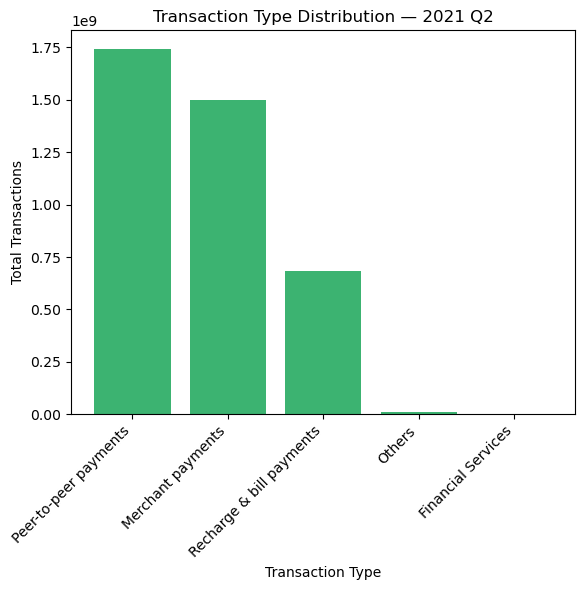

In [65]:
plt.figure(figsize=(6,6))
type_totals = recent_data.groupby('Transaction Type')['Transactions'].sum().sort_values(ascending=False)
plt.bar(type_totals.index, type_totals.values, color='mediumseagreen')
plt.title(f'Transaction Type Distribution — {Latest_year} Q{Latest_quarter}')
plt.xlabel('Transaction Type')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 2.8: Find unique mapping between district name and district code

#### 1. Identify the unique mapping between district names and district codes from the dataset. [hint: you can use drop_duplicates()]

In [66]:
mapping=district_txn[['District','Code']].drop_duplicates()

In [67]:
print(mapping)

                        District  Code
0                       Nicobars  AN01
1       North And Middle Andaman  AN02
2                  South Andaman  AN03
42                     Anantapur  AP01
43                      Chittoor  AP02
...                          ...   ...
9944             Purba Bardhaman  WB19
9945             Purba Medinipur  WB20
9946                     Purulia  WB21
9947  South Twenty Four Parganas  WB22
9948              Uttar Dinajpur  WB23

[732 rows x 2 columns]


#### 2. Create a CSV file containing the unique district name and district code mappings.

In [68]:
mapping.to_csv('district_code_mapping.csv', index=False)

## Task 3: Data Quality Checks

#### 3.1: Ensure data consistency across state and district levels

*Aggregating district-level data up to state level with `groupby('State').sum()`, then joining it against the actual state-level totals to check whether the two independently-reported datasets agree a standard data quality/reconciliation check.*

#### 1. For each state, calculate the total number of transactions, total transaction amount, and total registered users by summing up the values from the district level data.

In [69]:
district_agg=district_txn.groupby('State')[['Transactions','Amount (INR)','Registered Users']].sum()

In [70]:
district_agg

,Transactions,Amount (INR),Registered Users
State,,,
Andaman & Nicobar Islands,1223565,3.641818e+09,408396
Andhra Pradesh,1781091169,3.860292e+12,158007957
Arunachal Pradesh,8043799,2.225183e+10,1862214
Assam,123577981,2.814087e+11,26860751
Bihar,713643889,1.639579e+12,115284760
Chandigarh,25516542,5.371208e+10,3801466
Chhattisgarh,241908549,4.156353e+11,37448388
Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,2701112
Delhi,1011031124,1.649942e+12,95374654


#### 2. Compare the results with the corresponding values at the state level to ensure they match.

In [71]:
state_agg=state_txn.groupby('State')[['Transactions','Amount (INR)', 'Registered Users']].sum()

In [72]:
state_agg

,Transactions,Amount (INR),Registered Users
State,,,
Andaman & Nicobar Islands,1223565,3.641818e+09,408396
Andhra Pradesh,1781091169,3.187847e+12,158007957
Arunachal Pradesh,8043799,2.225183e+10,1862214
Assam,123577981,2.814087e+11,26860751
Bihar,713643889,1.639579e+12,115284760
Chandigarh,25516542,5.371208e+10,3801466
Chhattisgarh,241908549,4.156353e+11,37448388
Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,2701112
Delhi,1011031124,1.649942e+12,95374654


#### Comparing

In [73]:
comparison = state_agg.join(district_agg, lsuffix='_state', rsuffix='_district_sum')
print(comparison)

                                      Transactions_state  Amount (INR)_state  \
State                                                                          
Andaman & Nicobar Islands                        1223565        3.641818e+09   
Andhra Pradesh                                1781091169        3.187847e+12   
Arunachal Pradesh                                8043799        2.225183e+10   
Assam                                          123577981        2.814087e+11   
Bihar                                          713643889        1.639579e+12   
Chandigarh                                      25516542        5.371208e+10   
Chhattisgarh                                   241908549        4.156353e+11   
Dadra & Nagar Haveli and Daman & Diu            12462185        1.865878e+10   
Delhi                                         1011031124        1.649942e+12   
Goa                                             24481604        4.427187e+10   
Gujarat                                 

#### 3. Display any discrepancies found between the district-level and state-level data.

#### Highlight discrepancies

In [74]:
comparison['Transactions_diff'] = comparison['Transactions_state'] - comparison['Transactions_district_sum']
comparison['Amount_diff'] = comparison['Amount (INR)_state'] - comparison['Amount (INR)_district_sum']
comparison['Users_diff'] = comparison['Registered Users_state'] - comparison['Registered Users_district_sum']

discrepancies = comparison[
    (comparison['Transactions_diff'].abs() > 0) |
    (comparison['Amount_diff'].abs() > 0) |
    (comparison['Users_diff'].abs() > 0)
]


In [75]:
print(discrepancies)

                                      Transactions_state  Amount (INR)_state  \
State                                                                          
Andaman & Nicobar Islands                        1223565        3.641818e+09   
Andhra Pradesh                                1781091169        3.187847e+12   
Arunachal Pradesh                                8043799        2.225183e+10   
Assam                                          123577981        2.814087e+11   
Bihar                                          713643889        1.639579e+12   
Chandigarh                                      25516542        5.371208e+10   
Chhattisgarh                                   241908549        4.156353e+11   
Dadra & Nagar Haveli and Daman & Diu            12462185        1.865878e+10   
Delhi                                         1011031124        1.649942e+12   
Goa                                             24481604        4.427187e+10   
Gujarat                                 

## Task 4: Data Merging and Advanced Analysis

#### 4.1: Ratio of users to population by state

*Merging two datasets on `State` (or `State`+`District`) to bring together data that lives in separate sheets and its equivalent to a SQL JOIN.*

#### 1. Merge the State_Txn and Users dataset with the District Demographics dataset to calculate the ratio of registered users to the population for each state.Display the results in a tabular format

In [76]:
state_users=state_txn.groupby('State')['Registered Users'].sum().reset_index()

In [77]:
state_population=district_demo.groupby('State')['Population'].sum().reset_index()

In [78]:
merger=pd.merge(state_users,state_population,on='State')

In [79]:
merger['User_population_ratio']=merger['Registered Users']/merger['Population']

In [80]:
print(merger)

                                   State  Registered Users  Population  \
0              Andaman & Nicobar Islands            408396      380581   
1                         Andhra Pradesh         158007957    49378776   
2                      Arunachal Pradesh           1862214     1606047   
3                                  Assam          26860751    34461385   
4                                  Bihar         115284760   103817951   
5                             Chandigarh           3801466     1055450   
6                           Chhattisgarh          37448388    25867958   
7   Dadra & Nagar Haveli and Daman & Diu           2701112      586956   
8                                  Delhi          95374654    16787941   
9                                    Goa           4755320     1457723   
10                               Gujarat         126380032    65930328   
11                               Haryana          85564119    25855357   
12                      Himachal Prade

#### 2. Create a column chart depicting the ratio of users to population by state.

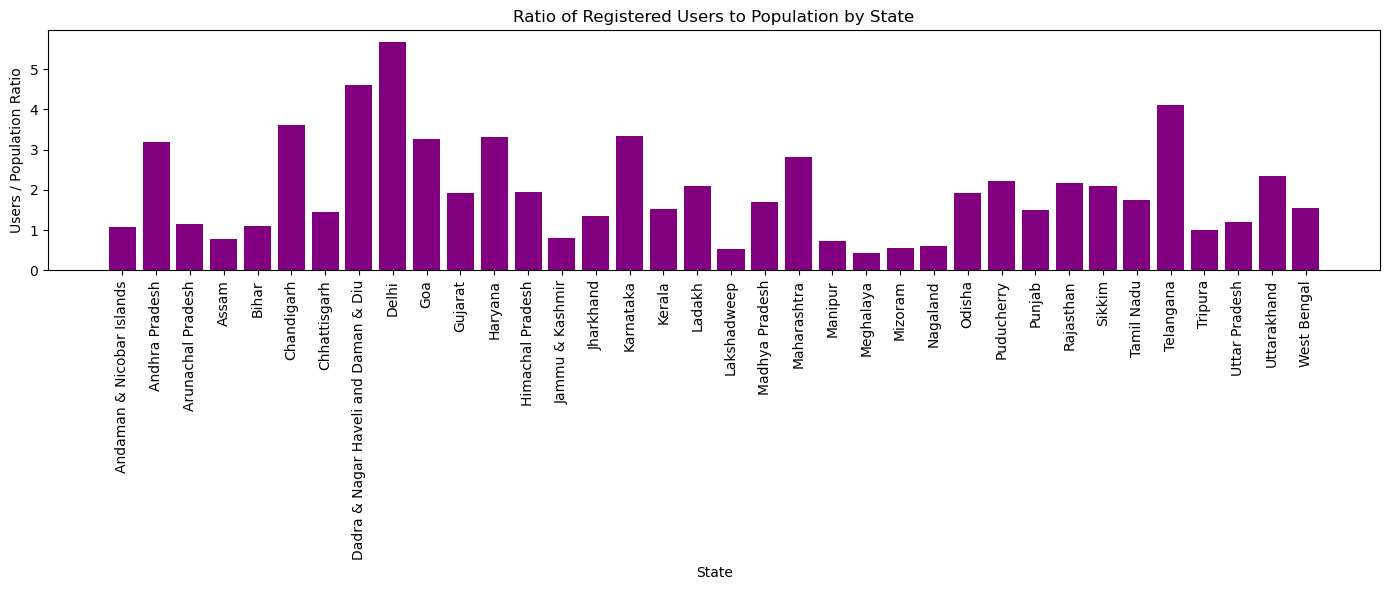

In [81]:
plt.figure(figsize=(14,6))
plt.bar(merger['State'], merger['User_population_ratio'], color='purple')
plt.title('Ratio of Registered Users to Population by State')
plt.xlabel('State')
plt.ylabel('Users / Population Ratio')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 4.2: Correlate population density with transaction volume

#### 1. Merge the District_Txn and Users dataset with the District Demographics dataset.

In [82]:
merge_dt_dd=pd.merge(
    district_txn.groupby(['State','District'])['Transactions'].sum().reset_index(),
    district_demo[['State','District','Density']],
    on=['State','District']
)

In [83]:
merge_dt_dd

,State,District,Transactions,Density
0,Andaman & Nicobar Islands,South Andaman,1014784,89
1,Andhra Pradesh,Anantapur,124411535,213
2,Andhra Pradesh,Chittoor,181284289,275
3,Andhra Pradesh,East Godavari,160754836,477
4,Andhra Pradesh,Guntur,160872479,429
...,...,...,...,...
623,West Bengal,Paschim Medinipur,37411450,757
624,West Bengal,Purba Bardhaman,45668162,890
625,West Bengal,Purba Medinipur,43394953,1076
626,West Bengal,Purulia,18265697,468


#### 2. Calculate the correlation between population density and transaction volume.

In [84]:
correlation=merge_dt_dd['Density'].corr(merge_dt_dd['Transactions'])

In [85]:
print(correlation)

0.41880419499596916


#### 3. Create a scatter plot to visualize the correlation between population density and transaction volume.

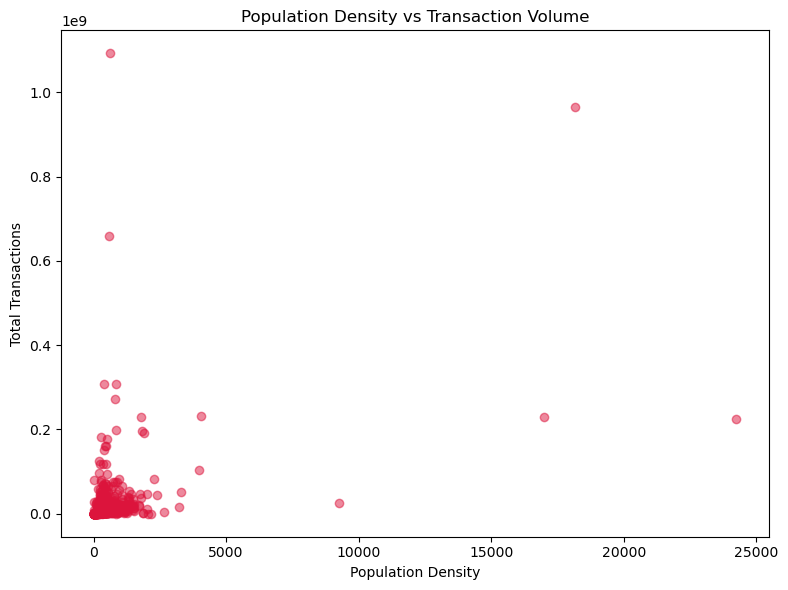

In [86]:
plt.figure(figsize=(8,6))
plt.scatter(merge_dt_dd['Density'], merge_dt_dd['Transactions'], alpha=0.5, color='crimson')
plt.title('Population Density vs Transaction Volume')
plt.xlabel('Population Density')
plt.ylabel('Total Transactions')
plt.tight_layout()
plt.show()

#### 4.3: Average transaction amount per user

#### 1. Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.

In [87]:
state_amt_users=state_txn.groupby('State')[['Amount (INR)','Registered Users']].sum().reset_index()

In [88]:
state_amt_users['Avg_amount_per_users']=state_amt_users['Amount (INR)']/state_amt_users['Registered Users']

In [89]:
print(state_amt_users)

                                   State  Amount (INR)  Registered Users  \
0              Andaman & Nicobar Islands  3.641818e+09            408396   
1                         Andhra Pradesh  3.187847e+12         158007957   
2                      Arunachal Pradesh  2.225183e+10           1862214   
3                                  Assam  2.814087e+11          26860751   
4                                  Bihar  1.639579e+12         115284760   
5                             Chandigarh  5.371208e+10           3801466   
6                           Chhattisgarh  4.156353e+11          37448388   
7   Dadra & Nagar Haveli and Daman & Diu  1.865878e+10           2701112   
8                                  Delhi  1.649942e+12          95374654   
9                                    Goa  4.427187e+10           4755320   
10                               Gujarat  1.105329e+12         126380032   
11                               Haryana  1.059832e+12          85564119   
12          

#### 2. Identify the top 5 states with the highest average transaction amount per user and the top 5 states with the lowest average transaction amount per user. Display the results.

#### Top_5 Highest Average Transaction Amount per User

In [90]:
top_5_Highest=state_amt_users.sort_values('Avg_amount_per_users',ascending=False).head(5)

In [91]:
print(top_5_Highest)

             State  Amount (INR)  Registered Users  Avg_amount_per_users
31       Telangana  4.574246e+12         149224214          30653.509622
15       Karnataka  4.361396e+12         203098564          21474.282206
1   Andhra Pradesh  3.187847e+12         158007957          20175.233763
28       Rajasthan  2.625584e+12         149770064          17530.768707
8            Delhi  1.649942e+12          95374654          17299.587909


#### Top_5 Lowest Average Transaction Amount per User

In [92]:
top_5_Lowest=state_amt_users.sort_values('Avg_amount_per_users',ascending=True).head(5)

In [93]:
print(top_5_Lowest)

                                   State  Amount (INR)  Registered Users  \
18                           Lakshadweep  1.921587e+08             34223   
32                               Tripura  2.097051e+10           3661575   
7   Dadra & Nagar Haveli and Daman & Diu  1.865878e+10           2701112   
16                                Kerala  3.729599e+11          51267042   
12                      Himachal Pradesh  9.786546e+10          13373980   

    Avg_amount_per_users  
18           5614.898889  
32           5727.184275  
7            6907.815954  
16           7274.846690  
12           7317.601442  


#### 4.4: Device brand usage ratio

#### 1. Merge the State_DeviceData dataset with the State_Txn and Users dataset.

In [94]:
merge_SD_ST=pd.merge(
    state_device,
    state_txn.groupby('State')['Registered Users'].sum().reset_index().rename(columns={'Registered Users':'Total_State_Users'}),
    on='State'
)

In [95]:
print(merge_SD_ST)

                          State  Year  Quarter    Brand  Registered Users  \
0     Andaman & Nicobar Islands  2018        1   Xiaomi              1665   
1     Andaman & Nicobar Islands  2018        1  Samsung              1445   
2     Andaman & Nicobar Islands  2018        1     Vivo               982   
3     Andaman & Nicobar Islands  2018        1     Oppo               501   
4     Andaman & Nicobar Islands  2018        1  OnePlus               332   
...                         ...   ...      ...      ...               ...   
5539                West Bengal  2021        2   Lenovo            350841   
5540                West Bengal  2021        2     Asus            297579   
5541                West Bengal  2021        2   Huawei            272965   
5542                West Bengal  2021        2    Apple            201393   
5543                West Bengal  2021        2   Others           1928653   

      Percentage  Total_State_Users  
0       0.247033             408396  

#### 2. Calculate the ratio of users using each device brand to the total number of registered users in each state. Display the results in a tabular format.

In [96]:
merge_SD_ST['Brand_Usage_Ratio']=merge_SD_ST['Registered Users']/merge_SD_ST['Total_State_Users']

In [97]:
print(merge_SD_ST[['State','Brand','Registered Users','Total_State_Users','Brand_Usage_Ratio']])

                          State    Brand  Registered Users  Total_State_Users  \
0     Andaman & Nicobar Islands   Xiaomi              1665             408396   
1     Andaman & Nicobar Islands  Samsung              1445             408396   
2     Andaman & Nicobar Islands     Vivo               982             408396   
3     Andaman & Nicobar Islands     Oppo               501             408396   
4     Andaman & Nicobar Islands  OnePlus               332             408396   
...                         ...      ...               ...                ...   
5539                West Bengal   Lenovo            350841          144242183   
5540                West Bengal     Asus            297579          144242183   
5541                West Bengal   Huawei            272965          144242183   
5542                West Bengal    Apple            201393          144242183   
5543                West Bengal   Others           1928653          144242183   

      Brand_Usage_Ratio  
0

#### 3. Create a bar chart depicting the device brand usage ratio for each state.

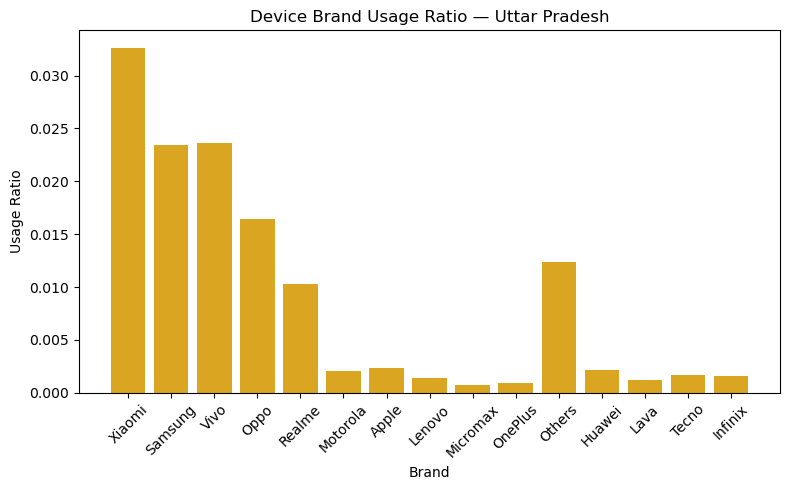

In [98]:
selected_state = 'Uttar Pradesh'
brand_data = merge_SD_ST[merge_SD_ST['State'] == selected_state]

plt.figure(figsize=(8,5))
plt.bar(brand_data['Brand'], brand_data['Brand_Usage_Ratio'], color='goldenrod')
plt.title(f'Device Brand Usage Ratio — {selected_state}')
plt.xlabel('Brand')
plt.ylabel('Usage Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 5: Data Visualization

#### 5.1: Plot the total transactions and amount over time for a selected state

*Using `twinx()` to plot Transactions and Amount on two different y-axes in the same chart, since their scales are very different (transactions in thousands, amount in crores).*

#### 1. Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state.


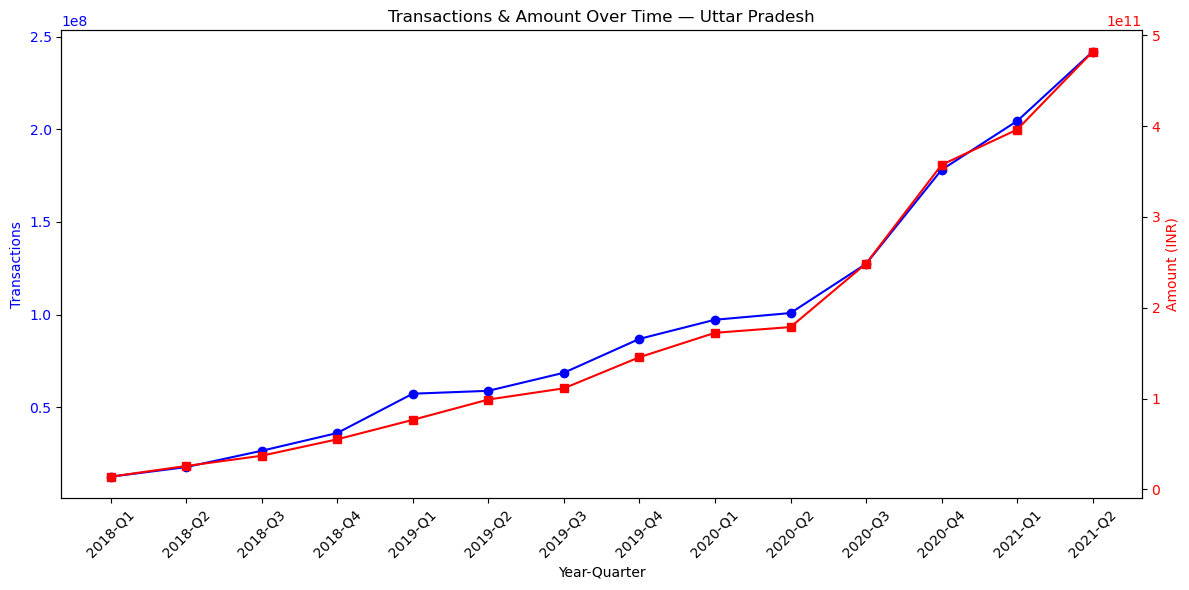

In [99]:
selected_state = 'Uttar Pradesh'

state_time = state_txn[state_txn['State'] == selected_state].copy()
state_time['Period'] = state_time['Year'].astype(str) + '-Q' + state_time['Quarter'].astype(str)
state_time = state_time.sort_values(['Year', 'Quarter'])

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(state_time['Period'], state_time['Transactions'], color='blue', marker='o', label='Transactions')
ax1.set_xlabel('Year-Quarter')
ax1.set_ylabel('Transactions', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(state_time['Period'], state_time['Amount (INR)'], color='red', marker='s', label='Amount (INR)')
ax2.set_ylabel('Amount (INR)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'Transactions & Amount Over Time — {selected_state}')
fig.tight_layout()
plt.show()

#### 5.2: Create a pie chart showing the distribution of transaction types for a specific quarter

#### 1. Create a pie chart showing the distribution of different transaction types for a selected state and quarter

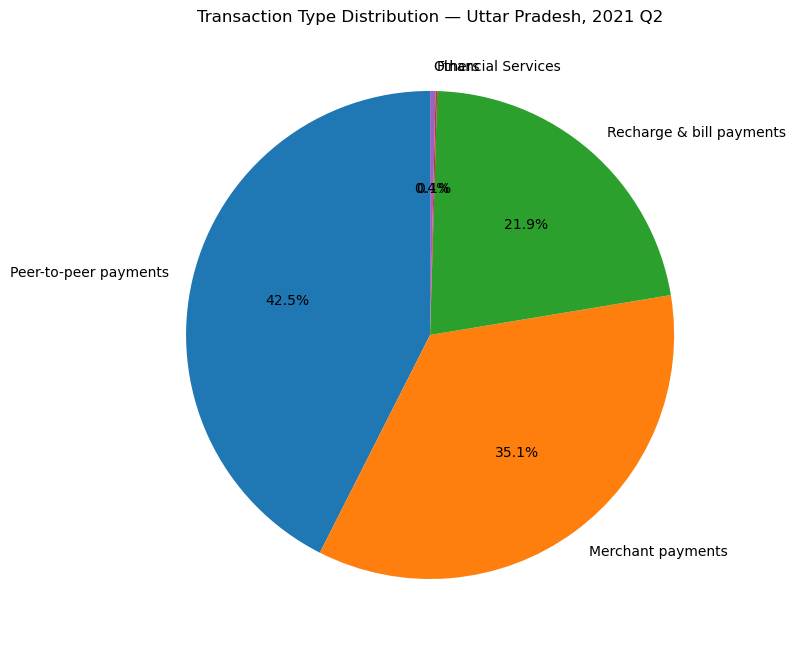

In [100]:
selected_state = 'Uttar Pradesh'
selected_year = 2021
selected_quarter = 2

pie_data = state_split[
    (state_split['State'] == selected_state) &
    (state_split['Year'] == selected_year) &
    (state_split['Quarter'] == selected_quarter)
]

plt.figure(figsize=(8,8))
plt.pie(pie_data['Transactions'], labels=pie_data['Transaction Type'], autopct='%1.1f%%', startangle=90)
plt.title(f'Transaction Type Distribution — {selected_state}, {selected_year} Q{selected_quarter}')
plt.tight_layout()
plt.show()

#### 5.3: Visualize the population density of districts in a selected state

#### 1. Create a bar plot showing the population density of districts in a selected state.

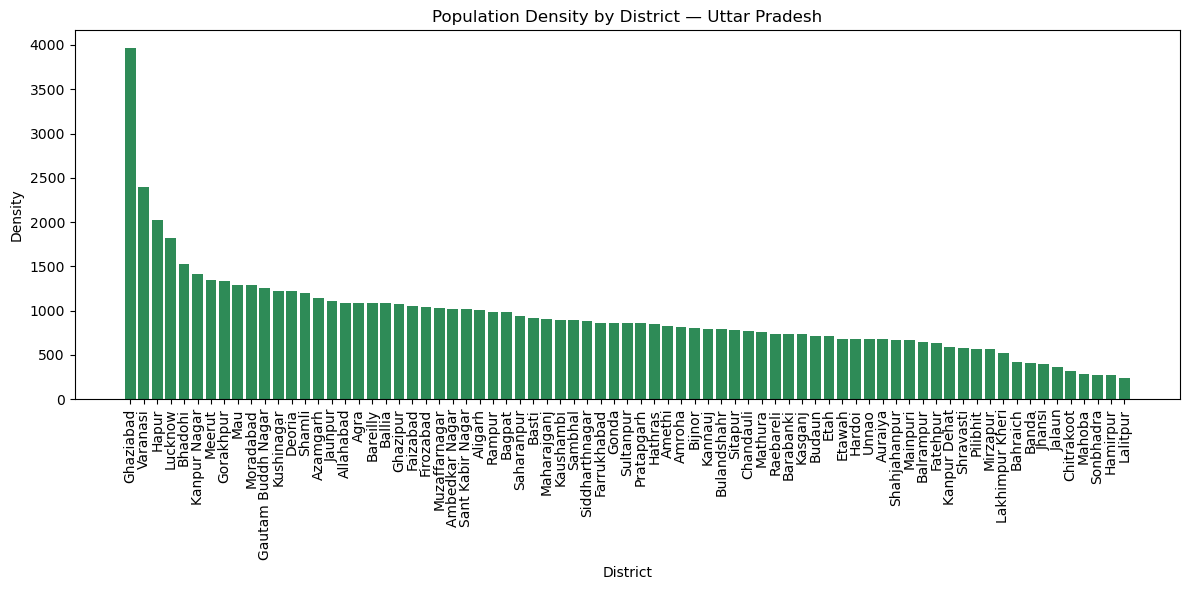

In [101]:
selected_state = 'Uttar Pradesh'
state_districts = district_demo[district_demo['State'] == selected_state].sort_values('Density', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(state_districts['District'], state_districts['Density'], color='seagreen')
plt.title(f'Population Density by District — {selected_state}')
plt.xlabel('District')
plt.ylabel('Density')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Task 6: Insights and Conclusions [Advanced Section]

#### 6.1: Identify any trends or patterns in the transaction data

#### 1. Analyze the transaction data to identify any noticeable trends or patterns. Summarize your findings. 

 Line graph at year level (aggregate across all states)

In [103]:
yearly_trend = state_txn.groupby('Year')[['Transactions', 'Amount (INR)']].sum()

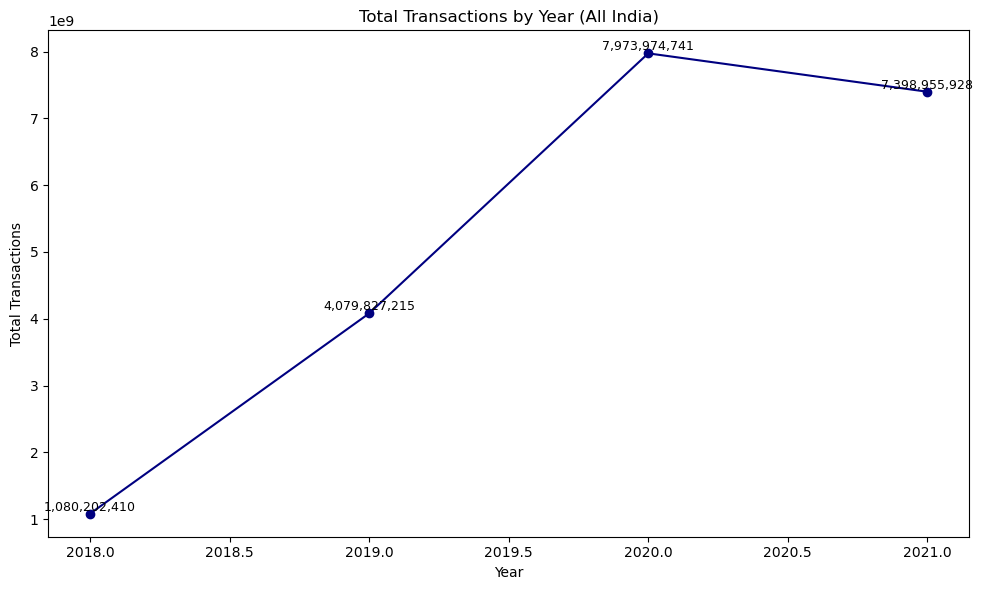

In [104]:

plt.figure(figsize=(10,6))
plt.plot(yearly_trend.index, yearly_trend['Transactions'], marker='o', color='navy')

for x, y in zip(yearly_trend.index, yearly_trend['Transactions']):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=9)

plt.title('Total Transactions by Year (All India)')
plt.xlabel('Year')
plt.ylabel('Total Transactions')
plt.tight_layout()
plt.show()

### Insights from the Chart

i.) Analysis of transaction data from 2018 to 2021 shows a consistent upward trend in both transaction volume and transaction amount across India.

ii.) Total transactions grew from approximately 1,080,202,410 in 2018 to 7,398,955,928 by 2021, Reflecting the rapid adoption of digital/UPI- based payments.

iii.) A dip shown from after 2020,likely linked to reduced offline commerce activity during COVID-19/lockdown.

#### 6.2: Correlate demographic data with transaction data

#### 1. Find correlations between demographic data (e.g., population density) and transaction data (e.g., transaction volume). Summarize your findings.

In [105]:
correlation_matrix=merge_dt_dd[['Density','Transactions']].corr()

In [106]:
print(correlation_matrix)

               Density  Transactions
Density       1.000000      0.418804
Transactions  0.418804      1.000000


### Insight from the table

i.) positive correlation → denser districts transact more (makes sense, more people + more merchants).

ii.) weak/near-zero → density alone doesn't explain transaction behavior well.

iii.) other factors (income, smartphone penetration, digital literacy) likely matters more.

#### 6.3: Summarize findings and insights

#### 1. Summarize the key findings and insights from your analysis. Provide actionable recommendations based on the data. 

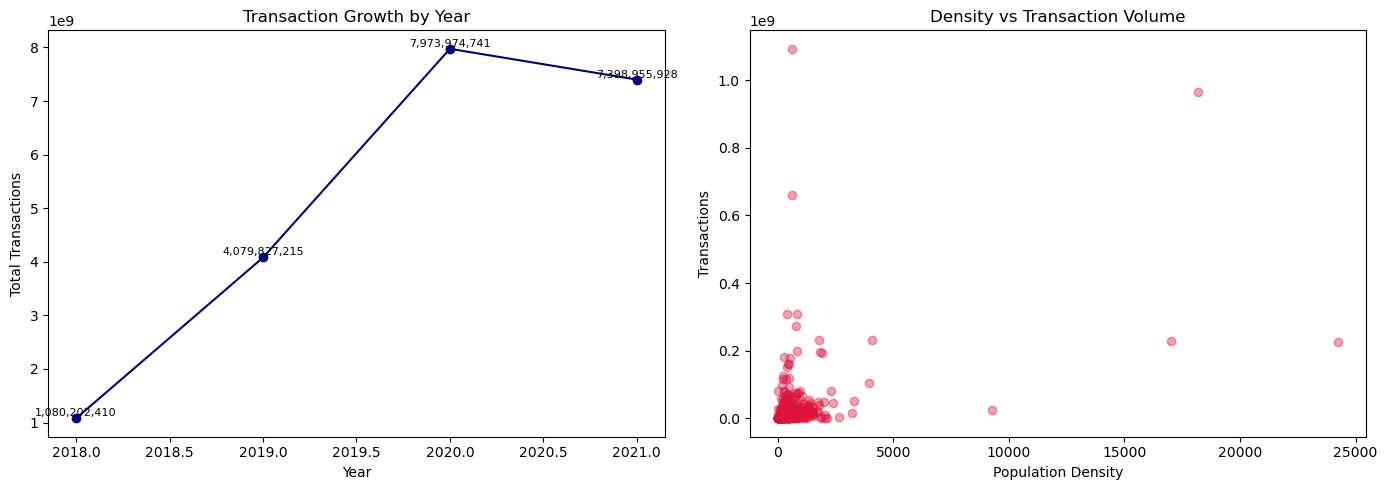

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Growth trend
axes[0].plot(yearly_trend.index, yearly_trend['Transactions'], marker='o', color='navy')
for x, y in zip(yearly_trend.index, yearly_trend['Transactions']):
    axes[0].text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
axes[0].set_title('Transaction Growth by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Transactions')

# Density vs transaction correlation
axes[1].scatter(merge_dt_dd['Density'], merge_dt_dd['Transactions'], alpha=0.4, color='crimson')
axes[1].set_title('Density vs Transaction Volume')
axes[1].set_xlabel('Population Density')
axes[1].set_ylabel('Transactions')

plt.tight_layout()
plt.show()

### Key Findings

1. Total transactions grew from 1.08B in 2018 to 7.97B in 2020 which is nearly 7x growth, reflecting rapid digital payment adoption nationally.

2. 2021 shows 7.4B transactions, appearing lower than 2020, but this reflects incomplete year coverage rather than an actual decline.

3. Population density shows a weak correlation with transaction volume, most high-transaction districts are not the highest-density ones, suggesting factors like income, digital literacy, and merchant infrastructure matter more than density alone.

4. Xiaomi and Vivo dominate device usage across most states, which is relevant for future device-partnership or app-optimization decisions.

5. Data quality checks confirmed strong consistency between state-level and district-level data — transaction counts and registered users matched exactly, with only negligible floating-point rounding differences (<0.01) in transaction amounts. A separate data gap was found in Lepa Rada district (Arunachal Pradesh), which had zero recorded population and area.

### Recommendations

1. Treat 2021 figures as partial-year data and normalize or annualize before making year-over-year growth claims.

2. Focus digital adoption campaigns on low-ATV, low-density states rather than assuming density alone drives growth.

3. Leverage dominant device brands (Xiaomi, Vivo) for co-branded promotions given their large combined user base.

4. Clean and validate known data gaps (e.g., Lepa Rada) before using this dataset for policy or business-critical decisions.

## Executive Summary Dashboard

A consolidated view of the key findings from this analysis — transaction growth, 
top/bottom performing states, average transaction value, population density 
correlation, and device brand usage — brought together in a single figure.

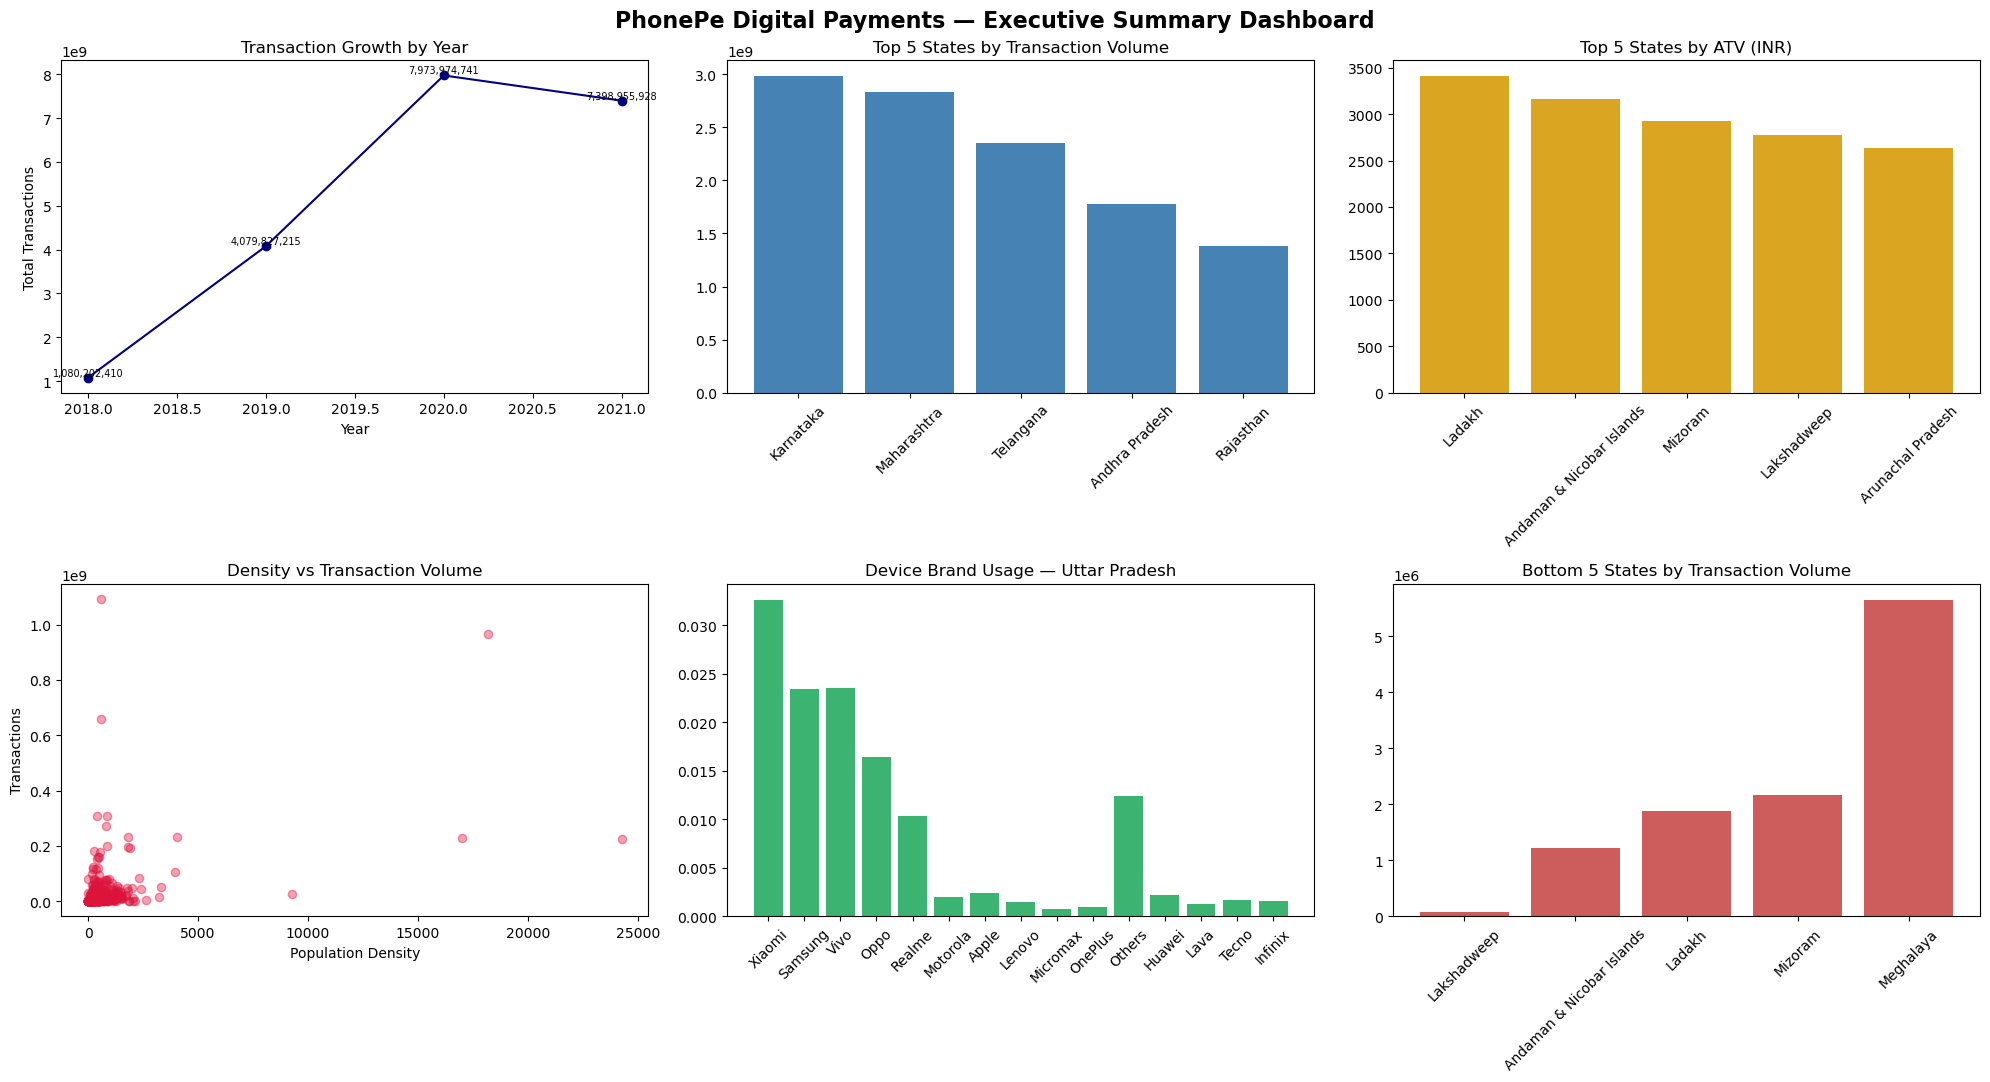

In [108]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. Yearly transaction growth
axes[0,0].plot(yearly_trend.index, yearly_trend['Transactions'], marker='o', color='navy')
for x, y in zip(yearly_trend.index, yearly_trend['Transactions']):
    axes[0,0].text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=7)
axes[0,0].set_title('Transaction Growth by Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Total Transactions')

# 2. Top 5 states by transaction volume
axes[0,1].bar(top_5.index, top_5['Transactions'], color='steelblue')
axes[0,1].set_title('Top 5 States by Transaction Volume')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Top 5 states by ATV
axes[0,2].bar(Top_5_highest_atv.index, Top_5_highest_atv.values, color='goldenrod')
axes[0,2].set_title('Top 5 States by ATV (INR)')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Density vs Transactions correlation
axes[1,0].scatter(merge_dt_dd['Density'], merge_dt_dd['Transactions'], alpha=0.4, color='crimson')
axes[1,0].set_title('Density vs Transaction Volume')
axes[1,0].set_xlabel('Population Density')
axes[1,0].set_ylabel('Transactions')

# 5. Device brand usage ratio (Uttar Pradesh, since that's your selected_state)
up_brands = merge_SD_ST[merge_SD_ST['State'] == 'Uttar Pradesh']
axes[1,1].bar(up_brands['Brand'], up_brands['Brand_Usage_Ratio'], color='mediumseagreen')
axes[1,1].set_title('Device Brand Usage — Uttar Pradesh')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Bottom 5 states by transaction volume
axes[1,2].bar(bottom_5.index, bottom_5['Transactions'], color='indianred')
axes[1,2].set_title('Bottom 5 States by Transaction Volume')
axes[1,2].tick_params(axis='x', rotation=45)

plt.suptitle('PhonePe Digital Payments — Executive Summary Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()